### T09 - Resampling

### ***Conceptual***

**1) Using basic statistical properties of the variance, as well as singlevariable calculus, derive (5.6). In other words, prove that α given by
(5.6) does indeed minimize Var(αX + (1 − α)Y ).**

Queremos minimizar:

$$
\text{Var}(\alpha X + (1 - \alpha)Y)
$$

Usando propiedades de varianza:

$$
\text{Var}(\alpha X + (1 - \alpha)Y)
= \alpha^2 \sigma_X^2
+ (1 - \alpha)^2 \sigma_Y^2
+ 2\alpha(1 - \alpha)\sigma_{XY}.
$$

Derivamos respecto a $\alpha$, igualamos a cero y resolvemos.  
El valor de $\alpha$ que minimiza la varianza es:

$$
\alpha =
\frac{\sigma_Y^2 - \sigma_{XY}}
     {\sigma_X^2 + \sigma_Y^2 - 2\sigma_{XY}}
$$

La segunda derivada es positiva, por lo que es un mínimo.


**2) We will now derive the probability that a given observation is part
of a bootstrap sample. Suppose that we obtain a bootstrap sample
from a set of n observations.**

Suponemos que tenemos una muestra original de tamaño $n$ y tomamos una muestra bootstrap de tamaño $n$ **con reemplazo**. Nos enfocamos en la observación $j$-ésima del conjunto original.

**a) What is the probability that the first bootstrap observation is
not the jth observation from the original sample? Justify your
answer.**


En cada extracción, todas las observaciones tienen probabilidad $1/n$ de ser elegidas.

La probabilidad de **no** elegir la observación $j$ es:

$$
P(\text{1a obs.} \neq j) = 1 - \frac{1}{n}.
$$


**b) What is the probability that the second bootstrap observation
is not the jth observation from the original sample?**

Cada extracción es independiente y con la misma distribución, por lo tanto:

$$
P(\text{2a obs.} \neq j) = 1 - \frac{1}{n}.
$$


**c) Argue that the probability that the jth observation is not in the
bootstrap sample is (1 − 1/n)n.**

Para que $j$ no aparezca en la muestra bootstrap, en las $n$ extracciones debe ocurrir que **nunca** se elige $j$.

La probabilidad de no elegir $j$ en una sola extracción es $1 - \frac{1}{n}$, y las extracciones son independientes. Entonces:

$$
P(\text{j no aparece en ninguna de las } n \text{ extracciones})
= \left(1 - \frac{1}{n}\right)^n.
$$


**d) When n = 5, what is the probability that the jth observation is
in the bootstrap sample?**

La probabilidad de que $j$ *no* aparezca es:

$$
\left(1 - \frac{1}{5}\right)^5 = \left(\frac{4}{5}\right)^5.
$$

Por lo tanto, la probabilidad de que $j$ **sí** esté en la muestra bootstrap es:

$$
P(\text{j está}) = 1 - \left(\frac{4}{5}\right)^5 \approx 0.672.
$$


**e) When n = 100, what is the probability that the jth observation
is in the bootstrap sample?**

Análogamente:

$$
P(\text{j está}) = 1 - \left(1 - \frac{1}{100}\right)^{100}
= 1 - \left(\frac{99}{100}\right)^{100}
\approx 0.634.
$$

**f) When n = 10, 000, what is the probability that the jth observation is in the bootstrap sample?**

$$
P(\text{j está}) = 1 - \left(1 - \frac{1}{10000}\right)^{10000}
= 1 - \left(\frac{9999}{10000}\right)^{10000}
\approx 0.632.
$$

**g) Create a plot that displays, for each integer value of n from 1
to 100, 000, the probability that the jth observation is in the
bootstrap sample. Comment on what you observe.**

La probabilidad de que $j$ esté en la muestra bootstrap de tamaño $n$ es:

$$
p_n = 1 - \left(1 - \frac{1}{n}\right)^n.
$$

Al graficar $p_n$ para $n = 1, 2, \dots, 100000$, se observa que:

- La probabilidad crece rápidamente al inicio.
- Después se estabiliza cerca del valor límite:

$$
\lim_{n \to \infty} p_n = 1 - e^{-1} \approx 0.632.
$$

Es decir, para muestras grandes, cualquier observación original aparece en una muestra bootstrap con probabilidad cercana a $0.632$.


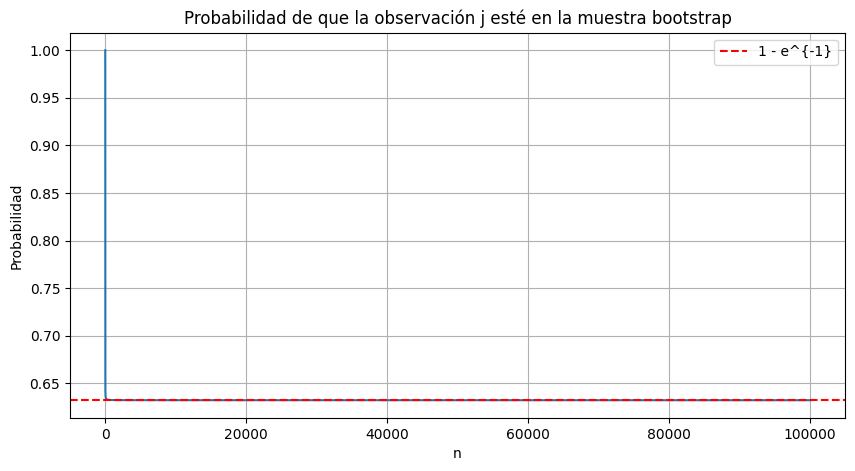

In [36]:
import numpy as np
import matplotlib.pyplot as plt


n_vals = np.arange(1, 100001)

# Probabilidad de que la observación j esté en la muestra bootstrap
prob = 1 - (1 - 1/n_vals)**n_vals

plt.figure(figsize=(10,5))
plt.plot(n_vals, prob)
plt.axhline(1 - np.exp(-1), color='red', linestyle='--', label='1 - e^{-1}')
plt.xlabel("n")
plt.ylabel("Probabilidad")
plt.title("Probabilidad de que la observación j esté en la muestra bootstrap")
plt.legend()
plt.grid(True)
plt.show()

La gráfica muestra que, a medida que n aumenta, la probabilidad de que una observación esté en una muestra bootstrap se estabiliza alrededor del 63%. Esto significa que incluso con muestras muy grandes, cada observación original NO aparece en el bootstrap aproximadamente un 37% de las veces, y sí aparece un 63%.

**h) We will now investigate numerically the probability that a bootstrap sample of size n = 100 contains the jth observation. Here
j = 4.**

In [38]:
import numpy as np

# Número de simulaciones
B = 10000

resultados = []

for _ in range(B):
    #Bootstrap de tamaño 100 de los índices 1,...,100
    muestra = np.random.choice(np.arange(1, 101), size=100, replace=True)
    resultados.append(4 in muestra)

#Probabilidad estimada
prob_estimada = np.mean(resultados)
prob_estimada

np.float64(0.6309)

**3) We now review k-fold cross-validation.**

**a) Explain how k-fold cross-validation is implemented.**

1. Se divide el conjunto de datos en $k$ subconjuntos (folds) de tamaño similar.
2. Para cada fold $l = 1, \dots, k$:
   - Se usan los otros $k-1$ folds como conjunto de **entrenamiento**.
   - El fold restante funciona como **conjunto de validación**.
   - Se ajusta el modelo con los datos de entrenamiento y se calcula el error en el fold de validación.
3. Se repite el proceso para los $k$ folds.
4. El error de validación final es el **promedio** de los $k$ errores obtenidos.

**b) What are the advantages and disadvantages of k-fold crossvalidation relative to:**

i. The validation set approach?

ii. LOOCV?

Comparación con el validation set approach:

**Ventajas:**
- Utiliza **todos los datos** para entrenar y validar (en distintas iteraciones).
- Reduce la **varianza** del error estimado, porque no depende de una sola partición del dataset.
- Más estable y más realista que usar un solo validation set.

**Desventajas:**
- Es más **costoso computacionalmente**, porque se entrena el modelo $k$ veces.

Comparación con LOOCV (Leave-One-Out Cross-Validation):

**Ventajas:**
- Requiere entrenar el modelo solo $k$ veces, mientras que LOOCV necesita entrenarlo $n$ veces → **mucho más eficiente**.
- Típicamente tiene **menor varianza** que LOOCV, porque los folds son menos parecidos entre sí que en LOOCV.

**Desventajas:**
- Tiene un **poco más de sesgo** que LOOCV, porque cada modelo se entrena con una porción algo más pequeña de los datos.
- El resultado depende de cómo se dividen los folds (LOOCV no tiene esta variabilidad).


**4)  Suppose that we use some statistical learning method to make a prediction for the response Y for a particular value of the predictor X.
Carefully describe how we might estimate the standard deviation of
our prediction.**




Volvemos a entrenar el modelo muchas veces con
versiones "ligeramente distintas" del mismo conjunto de datos y vemos
qué tanto cambian las predicciones en $x_0$. La variación de esas
predicciones nos da la desviación estándar (incertidumbre) de
$\hat{Y}(x_0)$.

### ***Aplicados***

In [2]:
!pip install ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 11.3 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=55310d1953579769c8a7bf214fb446001ca5ae1f31db2eb3620d3825114b8d4f
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ISLP import load_data
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

### 5)

a) Fit a logistic regression model that uses income and balance to
predict default.

In [4]:
default = load_data("Default")
y = default['default'].apply(lambda x: 1 if x == 'Yes' else 0)
X = default[['income', 'balance']]
X = sm.add_constant(X).astype(float)
model_5a = sm.GLM(y, X, family=sm.families.Binomial()).fit()
print(model_5a.params)

const     -11.540468
income      0.000021
balance     0.005647
dtype: float64


b) Using the validation set approach, estimate the test error of this
model.

In [5]:
np.random.seed(1)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5, random_state=1)
model_5b = sm.GLM(y_train, X_train, family=sm.families.Binomial()).fit()
y_val_prob = model_5b.predict(X_val)
y_val_pred = (y_val_prob > 0.5).astype(int)
val_error_5b = np.mean(y_val_pred != y_val)
print(val_error_5b)

0.025


c) Repeat the process in (b) three times, using three different splits
of the observations into a training set and a validation set.

In [6]:
val_errors_5c = []
for seed in [2, 3, 4]:
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5, random_state=seed)
    model = sm.GLM(y_train, X_train, family=sm.families.Binomial()).fit()
    y_val_pred = (model.predict(X_val) > 0.5).astype(int)
    val_errors_5c.append(np.mean(y_val_pred != y_val))
print(val_errors_5c)

[np.float64(0.0248), np.float64(0.0248), np.float64(0.0238)]



Los errores de validación varían ligeramente entre las divisiones. Los resultados son similares en magnitud.

d)  Now consider a logistic regression model that predicts the probability of default using income, balance, and a dummy variable
for student. Estimate the test error for this model using the validation set approach.

In [7]:
X2 = default[['income', 'balance', 'student']]
X2 = pd.get_dummies(X2, columns=['student'], drop_first=True)
X2 = sm.add_constant(X2).astype(float)
np.random.seed(1)
X2_train, X2_val, y2_train, y2_val = train_test_split(X2, y, test_size=0.5, random_state=1)
model_5d = sm.GLM(y2_train, X2_train, family=sm.families.Binomial()).fit()
y2_val_pred = (model_5d.predict(X2_val) > 0.5).astype(int)
val_error_5d = np.mean(y2_val_pred != y2_val)
print(val_error_5d)

0.0262


La inclusión de la variable dummy "estudiante" aumentó ligeramente la tasa de error de la prueba.

### 6)

a) Using the summary() and glm() functions, determine the estimated standard errors for the coefficients associated with income
and balance in a multiple logistic regression model that uses
both predictors.

In [8]:
np.random.seed(1)
glm_full = sm.GLM(y, X, family=sm.families.Binomial()).fit()
se_glm = glm_full.bse[['income', 'balance']]
print(se_glm)

income     0.000005
balance    0.000227
dtype: float64


b) Write a function, boot.fn(), that takes as input the Default data
set as well as an index of the observations, and that outputs
the coefficient estimates for income and balance in the multiple
logistic regression model.

In [9]:
def boot_fn(data, idx):
    sub = data.iloc[idx]
    Xb = sub[['income', 'balance']]
    Xb = sm.add_constant(Xb).astype(float)
    yb = sub['default'].apply(lambda x: 1 if x == 'Yes' else 0)
    modelb = sm.GLM(yb, Xb, family=sm.families.Binomial()).fit()
    return modelb.params[['income', 'balance']].values

c) Use the boot() function together with your boot.fn() function to
estimate the standard errors of the logistic regression coefficients
for income and balance.

In [10]:
B = 1000
n = default.shape[0]
boot_coefs = np.zeros((B, 2))
rng = np.random.default_rng(1)
for b in range(B):
    idx = rng.integers(0, n, n)
    boot_coefs[b, :] = boot_fn(default, idx)
boot_se = boot_coefs.std(axis=0)
print(pd.Series(boot_se, index=['income', 'balance']))

income     0.000005
balance    0.000226
dtype: float64


d) Comment on the estimated standard errors obtained using the
glm() function and using your bootstrap function.

In [11]:
print("GLM SEs:", se_glm.values)
print("Bootstrap SEs:", boot_se)

GLM SEs: [4.98524546e-06 2.27381384e-04]
Bootstrap SEs: [4.87116546e-06 2.25799772e-04]


Los errores estándar estimados son muy similares, las estimaciones realizadas con el método bootstrap son ligeramente inferiores.


### 7)

In [12]:
Weekly = load_data("Weekly")
Weekly['Direction_binary'] = Weekly['Direction'].apply(lambda x: 1 if x == 'Up' else 0)
Xw = Weekly[['Lag1', 'Lag2']]
Xw = sm.add_constant(Xw).astype(float)
yw = Weekly['Direction_binary']

a) Fit a logistic regression model that predicts Direction using Lag1
and Lag2.

In [13]:
model_7a = sm.GLM(yw, Xw, family=sm.families.Binomial()).fit()
print("Coefficients:")
print(model_7a.params)

Coefficients:
const    0.221224
Lag1    -0.038722
Lag2     0.060248
dtype: float64


b)  Fit a logistic regression model that predicts Direction using Lag1
and Lag2 using all but the first observation.

In [14]:
Xw_leave1 = Xw.drop(index=0)
yw_leave1 = yw.drop(index=0)
model_7b = sm.GLM(yw_leave1, Xw_leave1, family=sm.families.Binomial()).fit()
print("Coefficients:")
print(model_7b.params)

Coefficients:
const    0.223243
Lag1    -0.038433
Lag2     0.060848
dtype: float64


c) Use the model from (b) to predict the direction of the first observation. You can do this by predicting that the first observation
will go up if P(Direction="Up"|Lag1, Lag2) > 0.5. Was this observation correctly classified?

In [15]:
X_first = Xw.iloc[0:1]
y_first = yw.iloc[0]
pred_prob_first = model_7b.predict(X_first).iloc[0]
pred_class_first = int(pred_prob_first > 0.5)
print("Posterior probability (Up):", pred_prob_first)
print("Predicted class:", pred_class_first, "Actual class:", int(y_first))
print("Correctly classified?", pred_class_first == int(y_first))

Posterior probability (Up): 0.5713923205204429
Predicted class: 1 Actual class: 0
Correctly classified? False


d) Perform full LOOCV loop manually

In [16]:
n_week = Xw.shape[0]
errors_7d = np.zeros(n_week, dtype=int)
for i in range(n_week):
    Xi_train = Xw.drop(index=i)
    yi_train = yw.drop(index=i)
    Xi_test = Xw.iloc[i:i+1]
    yi_test = yw.iloc[i]
    model_i = sm.GLM(yi_train, Xi_train, family=sm.families.Binomial()).fit()
    p_i = model_i.predict(Xi_test).iloc[0]
    pred_i = int(p_i > 0.5)
    errors_7d[i] = int(pred_i != int(yi_test))

e)  Take the average of the n numbers obtained in (d)iv in order to
obtain the LOOCV estimate for the test error. Comment on the
results.

In [17]:
loocv_error_7 = errors_7d.mean()
print("LOOCV classification error:", loocv_error_7)

LOOCV classification error: 0.44995408631772266


El LOOCV tuvo un desempeño muy malo en el conjunto de datos semanales, siendo apenas mejor que una mejor oportunidad.

### 8)

a) n, p and model in equation form

In [18]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y_sim = x - 2 * x**2 + rng.normal(size=100)
print("n =", len(y_sim), "p = 1")
print("Model: y = x - 2x² + ε")

n = 100 p = 1
Model: y = x - 2x² + ε


b) Create a scatterplot of X against Y . Comment on what you find.

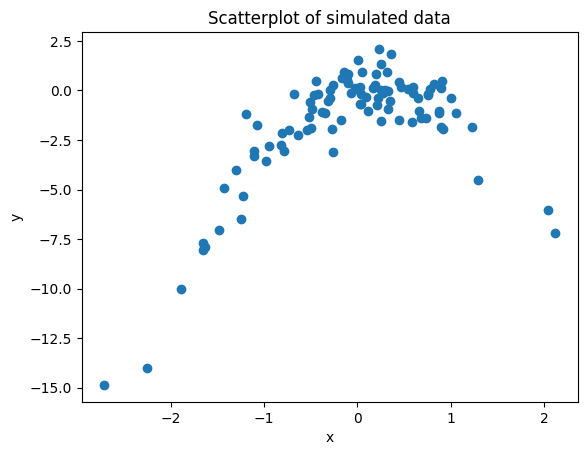

In [19]:
plt.scatter(x, y_sim)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatterplot of simulated data")
plt.show()

La gráfica parece una parábola inversa, lo que tiene sentido considerando que los datos generados provienen de un modelo cuadrático.

c) Compute LOOCV MSE for polynomial degrees 1–4.

In [20]:
def loocv_poly(x_arr, y_arr, degree):
    n_local = len(y_arr)
    errors_local = np.zeros(n_local)
    for i in range(n_local):
        x_train = np.delete(x_arr, i)
        y_train = np.delete(y_arr, i)
        X_poly = np.vander(x_train, N=degree+1, increasing=True)
        model = sm.OLS(y_train, X_poly).fit()
        X_test = np.vander([x_arr[i]], N=degree+1, increasing=True)
        y_pred = model.predict(X_test)
        errors_local[i] = (y_arr[i] - y_pred[0])**2
    return errors_local.mean()

np.random.seed(1)
loocv_errors_seed1 = [loocv_poly(x, y_sim, d) for d in range(1, 5)]
print("LOOCV MSEs (seed 1):", loocv_errors_seed1)

LOOCV MSEs (seed 1): [np.float64(6.633029839181983), np.float64(1.1229368563419686), np.float64(1.3017965489358874), np.float64(1.3323942694179305)]


d)  Repeat (c) using another random seed, and report your results.
Are your results the same as what you got in (c)? Why?

In [21]:
np.random.seed(2)
loocv_errors_seed2 = [loocv_poly(x, y_sim, d) for d in range(1, 5)]
print("LOOCV MSEs (seed 2):", loocv_errors_seed2)

LOOCV MSEs (seed 2): [np.float64(6.633029839181983), np.float64(1.1229368563419686), np.float64(1.3017965489358874), np.float64(1.3323942694179305)]


Los resultados son los mismos porque eliminamos una observación del conjunto de entrenamiento. No hay ningún efecto aleatorio derivado de las observaciones utilizadas para el conjunto de prueba. LOOCV no cambiará si modificamos la semilla aleatoria.

e) Which of the models in (c) had the smallest LOOCV error? Is
this what you expected? Explain your answer.

In [22]:
min_idx = int(np.argmin(loocv_errors_seed1) + 1)
print("Degree with smallest LOOCV MSE:", min_idx)

Degree with smallest LOOCV MSE: 2



Esto se ajusta a las expectativas ya que el modelo verdadero es cuadrático.

f) Comment on the statistical significance of the coefficient estimates that results from fitting each of the models in (c) using
least squares. Do these results agree with the conclusions drawn
based on the cross-validation results?

In [23]:
for d in range(1, 5):
    Xd = np.vander(x, N=d+1, increasing=True)
    mod = sm.OLS(y_sim, Xd).fit()
    print(f"8(f) Degree {d} model coefficients and p-values:")
    params = pd.concat([
        pd.Series(mod.params, name="coef"),
        pd.Series(mod.pvalues, name="pval")
    ], axis=1).round(4)
    print(params)
    print()

8(f) Degree 1 model coefficients and p-values:
     coef  pval
0 -1.4650   0.0
1  1.9494   0.0

8(f) Degree 2 model coefficients and p-values:
     coef    pval
0 -0.0728  0.5428
1  0.9663  0.0000
2 -2.0047  0.0000

8(f) Degree 3 model coefficients and p-values:
     coef    pval
0 -0.0572  0.6345
1  1.1146  0.0000
2 -2.0471  0.0000
3 -0.0643  0.2872

8(f) Degree 4 model coefficients and p-values:
     coef    pval
0  0.1008  0.4596
1  0.9050  0.0000
2 -2.5059  0.0000
3  0.0338  0.6425
4  0.1042  0.0231



El primer modelo presenta una tasa de error muy alta, por lo que los valores p de las estimaciones de los coeficientes no son demasiado importantes. En modelos mejores, observamos que la intersección no es significativa y que añadir términos polinómicos de mayor valor empeora el error, con lo que concuerdan los valores p.

### 9)

a) Based on this data set, provide an estimate for the population
mean of medv. Call this estimate ˆμ.

In [24]:
Boston = load_data("Boston")
medv = Boston['medv']
mi_hat = medv.mean()
print("mi_hat =", mi_hat)

mi_hat = 22.532806324110677


b) Provide an estimate of the standard error of ˆμ. Interpret this
result.

In [25]:
se_mi = medv.std(ddof=1) / np.sqrt(len(medv))
print("standard error of mi_hat =", se_mi)

standard error of mi_hat = 0.4088611474975351


El error estándar de la estimación de la media poblacional nos da una idea de cuánto podrían variar los datos cuando muestreamos la población.

c) Now estimate the standard error of ˆμ using the bootstrap. How
does this compare to your answer from (b)?

In [26]:
B = 1000
rng = np.random.default_rng(1)
boot_means = np.array([medv.sample(frac=1, replace=True, random_state=int(rng.integers(0, 1e9))).mean() for _ in range(B)])
se_mi_boot = boot_means.std(ddof=1)
print("bootstrap SE of mi_hat =", se_mi_boot)

bootstrap SE of mi_hat = 0.40734230823165357


Bootstrap SE es marginalmente más pequeño que la respuesta de (b), podemos decir que están de acuerdo en el resultado.

d) Based on your bootstrap estimate from (c), provide a 95 % confidence interval for the mean of medv. Compare it to the results
obtained using t.test(Boston$medv).

In [27]:
ci_95_boot = [mi_hat - 2*se_mi_boot, mi_hat + 2*se_mi_boot]
ci_95_two_se = [mi_hat - 2*se_mi, mi_hat + 2*se_mi]
print("95% CI (bootstrap):", ci_95_boot)
print("95% CI (two SE rule):", ci_95_two_se)

95% CI (bootstrap): [np.float64(21.71812170764737), np.float64(23.347490940573984)]
95% CI (two SE rule): [np.float64(21.715084029115605), np.float64(23.35052861910575)]


Los resultados son practicamente iguales

e) Based on this data set, provide an estimate, ˆμmed, for the median
value of medv in the population.

In [28]:
mu_med_hat = medv.median()
print("Sample median =", mu_med_hat)

Sample median = 21.2


f) We now would like to estimate the standard error of ˆμmed. Unfortunately, there is no simple formula for computing the standard
error of the median. Instead, estimate the standard error of the
median using the bootstrap. Comment on your findings.

In [29]:
boot_meds = np.array([medv.sample(frac=1, replace=True, random_state=int(rng.integers(0,1e9))).median() for _ in range(B)])
se_median_boot = boot_meds.std(ddof=1)
print("Bootstrap SE of median =", se_median_boot)
print()

Bootstrap SE of median = 0.37068186500696904



El SE de la mediana es menor que el SE de la media. Esto indica una distribución no normal de la media.

g) Based on this data set, provide an estimate for the tenth percentile of medv in Boston suburbs. Call this quantity ˆμ0.1. (You
can use the quantile() function.)

In [31]:
p10_hat = np.percentile(medv, 10)
print("10th percentile =", p10_hat)

10th percentile = 12.75


h) Use the bootstrap to estimate the standard error of ˆμ0.1. Comment on your findings.

In [32]:
boot_p10 = np.array([np.percentile(medv.sample(frac=1, replace=True, random_state=int(rng.integers(0,1e9))), 10) for _ in range(B)])
se_p10_boot = boot_p10.std(ddof=1)
print("Bootstrap SE of 10th percentile =", se_p10_boot)

Bootstrap SE of 10th percentile = 0.5111307583702551
